In [1]:
import numpy as np
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import skimage
import sys
import os
import networkx as nx

from matplotlib.ticker import MaxNLocator
import matplotlib as mpl
import matplotlib.tri as mtri
import cmath
import matplotlib.colors as colors
from skimage import measure
from numpy.linalg import inv
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression

from numpy import ones,vstack
from numpy.linalg import lstsq

In [2]:
sys.path.append("/Users/danyunhe/sknw")
import sknw

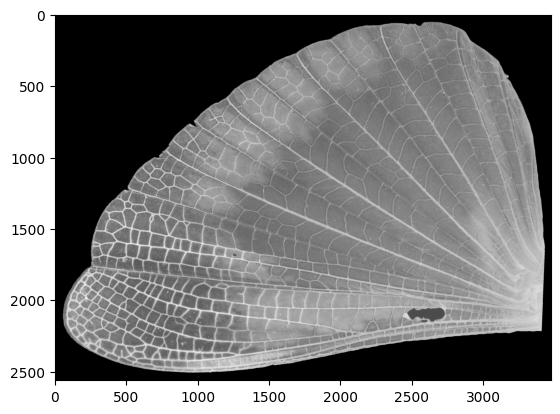

In [3]:
# Read image 
img_idx=10
dir="./images/"
# img=cv2.imread(dir+'0.png')
img = mpimg.imread(dir+'%d.png'%img_idx)
[x1,y1,z1]=img.shape
plt.imshow(img)

In [4]:
[x1,y1,z1]=img.shape

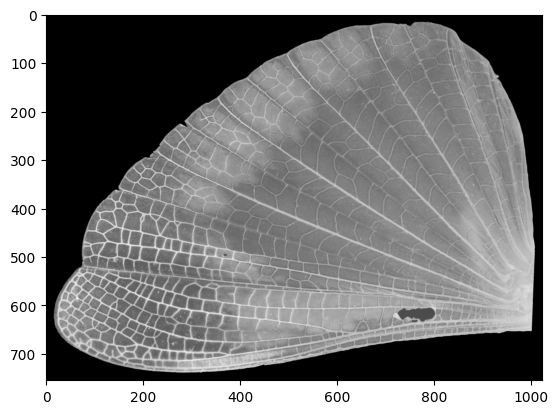

In [5]:
# new_img=cv2.imread(dir+'new_0.png')
new_img = mpimg.imread(dir+'new_%d.png'%img_idx)
[x2,y2]=new_img.shape
plt.imshow(new_img,cmap='gray')

In [6]:
data=pd.read_csv('./wing_47-danyun-2023-12-11/labeled-data/out47/CollectedData_danyun.csv')

In [7]:
data.iloc[2+29,0:]

scorer             labeled-data
Unnamed: 1                out47
Unnamed: 2            img29.png
danyun        94.97683438097617
danyun.1      517.5176991814709
                    ...        
danyun.55     595.6832182950297
danyun.56     675.1386873571684
danyun.57      624.343908636668
danyun.58      972.167659988692
danyun.59     593.9462067591729
Name: 31, Length: 63, dtype: object

In [8]:
img0_x=np.zeros(30)
img0_y=np.zeros(30)

for i in range(30):
    img0_x[i]=float(data.iloc[2+img_idx,3+i*2])
    img0_y[i]=float(data.iloc[2+img_idx,3+i*2+1])
    

In [18]:
cv2.imshow('img',new_img)

In [19]:
img0_x

array([ 77.17918951, 149.72887591, 228.70701554, 287.48144504,
       351.7659773 , 413.29545817, 495.94699965, 567.57833559,
       668.59688629, 736.55482039, 826.55316555, 860.5321326 ,
       910.12305749, 960.63233283, 951.44882822, 946.85707592,
       945.020375  , 960.63233283, 983.59109435, 997.36635127,
       551.96637776, 599.72060172, 654.82162937, 744.81997454,
       821.04306279, 901.85790334, 954.20387961,  29.38679625,
       637.37297062, 969.81583744])

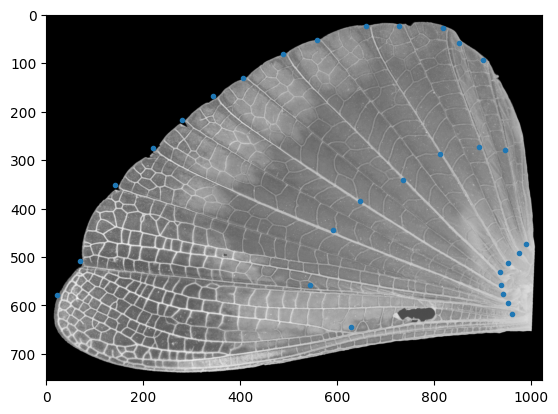

In [9]:
plt.imshow(new_img,cmap='gray')
plt.plot(img0_x-8,img0_y,'.')

In [210]:
y1/y2

3.3935546875

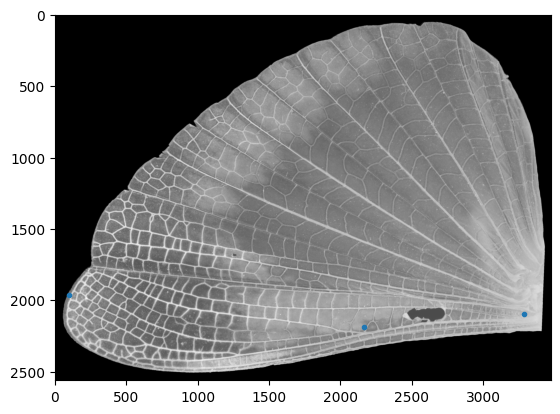

In [10]:
img_x=img0_x*x1/x2
img_y=img0_y*y1/y2
plt.imshow(img,cmap='gray')
plt.plot(img0_x[27:]*x1/x2,img0_y[27:]*x1/x2,'.')

In [134]:
img[2500,0]
img0_x[27:]*x1/x2,img0_y[27:]*x1/x2

array([0., 0., 0.], dtype=float32)

In [151]:
# get line segment 
xlen=img_x[28]-img_x[27]
ylen=img_y[28]-img_y[27]
num_pt=10
dx=xlen/(num_pt+1)
dy=ylen/(num_pt+1)

pt=np.zeros((num_pt+2,2))

for i in range(num_pt+2):
    pt[i,0]=img_x[27]+dx*i
    pt[i,1]=img_y[27]+dy*i
    

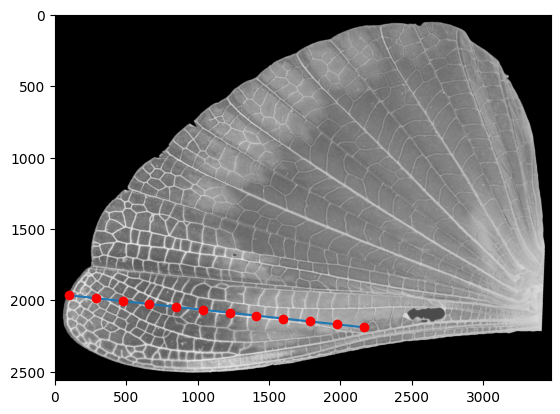

In [153]:
plt.imshow(img,cmap='gray')
plt.plot(img_x[27:29],img_y[27:29],'-')
plt.plot(pt[:,0],pt[:,1],'ro')


In [169]:
sum(img[2200,int(pt[0,0])])

2.258823573589325

In [173]:
bdy_pt=np.zeros((len(pt),2))
for j in range(len(pt)):
    for i in range(int(pt[j,1]),x1,1):
        if sum(img[i,int(pt[j,0])])<0.1:
            print(i)
            bdy_pt[j,0]=pt[j,0]
            bdy_pt[j,1]=i
            break


2245
2378
2449
2488
2504
2507
2499
2476
2450
2415
2378
2339


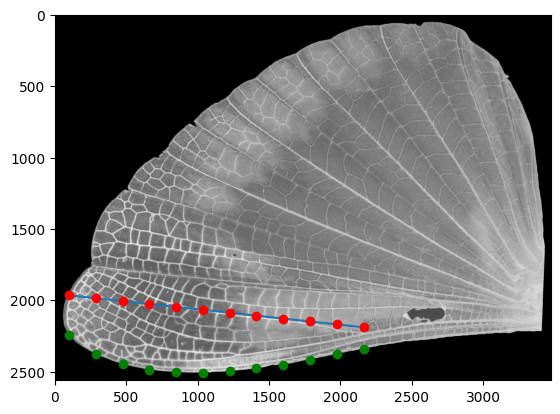

In [174]:
plt.imshow(img,cmap='gray')
plt.plot(img_x[27:29],img_y[27:29],'-')
plt.plot(pt[:,0],pt[:,1],'ro')
plt.plot(bdy_pt[:,0],bdy_pt[:,1],'go')

In [198]:
# find the bottom boundary points 
def find_hbdy(a,b,num_pt=10):
    # get line segment 
    xlen=b[0]-a[0]
    ylen=b[1]-a[1]
    dx=xlen/(num_pt+1)
    dy=ylen/(num_pt+1)

    pt=np.zeros((num_pt+2,2))

    for i in range(num_pt+2):
        pt[i,0]=a[0]+dx*i
        pt[i,1]=a[1]+dy*i
    
    bdy_pt=np.zeros((num_pt+2,2))

    for j in range(num_pt+2):
        for i in range(int(pt[j,1]),x1,1):
            if sum(img[i,int(pt[j,0])])<0.1:
                print(i)
                bdy_pt[j,0]=pt[j,0]
                bdy_pt[j,1]=i
                break
            
    return bdy_pt

In [199]:
a=[img_x[28],img_y[28]]
b=[img_x[29],img_y[29]]
bdy_pt2=find_hbdy(a,b)

2339
2320
2306
2289
2281
2273
2257
2249
2240
2231
2231
2220


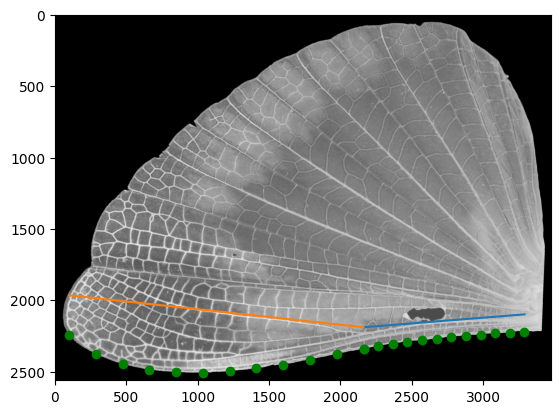

In [200]:
plt.imshow(img,cmap='gray')
plt.plot(img_x[28:],img_y[28:],'-')
plt.plot(bdy_pt2[:,0],bdy_pt2[:,1],'go')
plt.plot(img_x[27:29],img_y[27:29],'-')
plt.plot(bdy_pt[:,0],bdy_pt[:,1],'go')

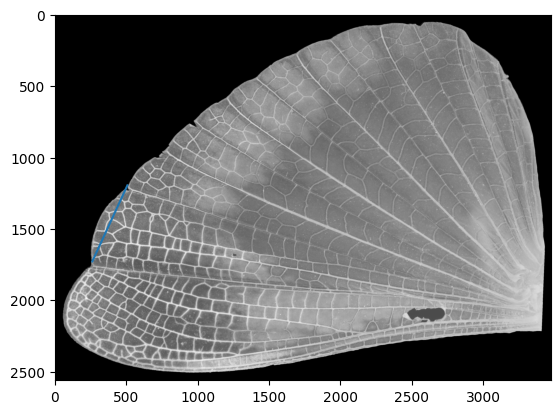

In [185]:
plt.imshow(img,cmap='gray')
plt.plot(img_x[0:2],img_y[0:2],'-')

In [255]:
# find the left boundary points 
def find_vbdy(a,b,num_pt=5):
    # get line segment 
    xlen=b[0]-a[0]
    ylen=b[1]-a[1]
    dx=xlen/(num_pt+1)
    dy=ylen/(num_pt+1)
    # print(dx,dy)
    

    pt=np.zeros((num_pt+2,2))

    for i in range(num_pt+2):
        pt[i,0]=a[0]+dx*i
        pt[i,1]=a[1]+dy*i
    
    bdy_pt=np.zeros((num_pt+2,2))

    dhx=dx/np.sqrt(dx*dx+dy*dy)
    dhy=dy/np.sqrt(dx*dx+dy*dy)
    for j in range(num_pt+2):
        for i in range(100):
            x=int(dhy*i+pt[j,0])
            y=int(pt[j,1]-dhx*i)
            # print(x,y)
            
            if sum(img[y,x])<0.1:
                print(i)
                bdy_pt[j,0]=x
                bdy_pt[j,1]=y
                break
            
    return bdy_pt,pt

In [207]:
a=[img_x[0],img_y[0]]
b=[img_x[1],img_y[1]]
result,pt=find_vbdy(a,b)

41.01539666367561 -88.81946656770045
261 1727
260 1727
259 1726
259 1726
258 1726
257 1725
256 1725
255 1724
7
302 1638
301 1638
300 1638
300 1637
299 1637
298 1636
297 1636
296 1636
295 1635
294 1635
293 1634
292 1634
291 1633
291 1633
290 1633
289 1632
288 1632
287 1631
286 1631
285 1631
284 1630
283 1630
282 1629
281 1629
281 1628
280 1628
279 1628
278 1627
277 1627
276 1626
275 1626
274 1625
273 1625
272 1625
271 1624
271 1624
270 1623
269 1623
268 1623
267 1622
266 1622
265 1621
264 1621
263 1620
262 1620
261 1620
261 1619
260 1619
259 1618
258 1618
257 1618
256 1617
255 1617
254 1616
253 1616
252 1615
55
343 1550
342 1549
342 1549
341 1548
340 1548
339 1548
338 1547
337 1547
336 1546
335 1546
334 1545
333 1545
332 1545
332 1544
331 1544
330 1543
329 1543
328 1543
327 1542
326 1542
325 1541
324 1541
323 1540
322 1540
322 1540
321 1539
320 1539
319 1538
318 1538
317 1537
316 1537
315 1537
314 1536
313 1536
312 1535
312 1535
311 1535
310 1534
309 1534
308 1533
307 1533
306 1532
305 

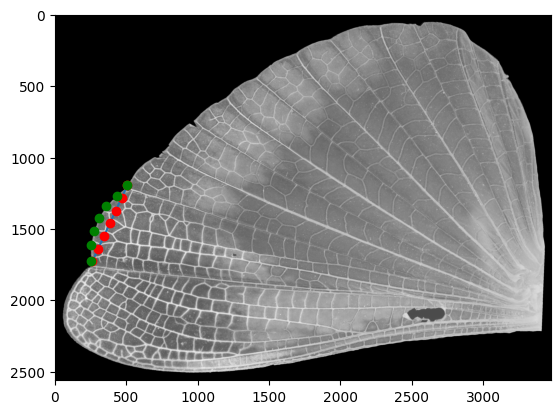

In [208]:
plt.imshow(img,cmap='gray')
plt.plot(img_x[0:2],img_y[0:2],'-')
plt.plot(pt[:,0],pt[:,1],'ro')
plt.plot(result[:,0],result[:,1],'go')

In [209]:
a=[img_x[1],img_y[1]]
b=[img_x[2],img_y[2]]
result,pt=find_vbdy(a,b)

44.649672317419004 -43.111203070872115
507 1194
0
552 1151
551 1151
551 1150
550 1149
549 1148
549 1148
548 1147
547 1146
546 1146
546 1145
545 1144
544 1143
544 1143
543 1142
542 1141
542 1140
541 1140
540 1139
17
597 1108
596 1107
595 1107
595 1106
594 1105
593 1105
593 1104
592 1103
591 1102
590 1102
590 1101
589 1100
588 1100
588 1099
587 1098
586 1097
586 1097
585 1096
584 1095
583 1094
583 1094
582 1093
581 1092
581 1092
580 1091
579 1090
579 1089
578 1089
577 1088
577 1087
29
641 1065
641 1064
640 1064
639 1063
639 1062
638 1061
637 1061
636 1060
636 1059
635 1059
634 1058
634 1057
633 1056
632 1056
632 1055
631 1054
630 1054
630 1053
629 1052
628 1051
627 1051
627 1050
626 1049
625 1048
625 1048
624 1047
623 1046
623 1046
622 1045
28
686 1022
685 1021
685 1020
684 1020
683 1019
683 1018
682 1018
681 1017
680 1016
680 1015
679 1015
678 1014
678 1013
677 1013
676 1012
676 1011
675 1010
16
731 979
0
775 936
0


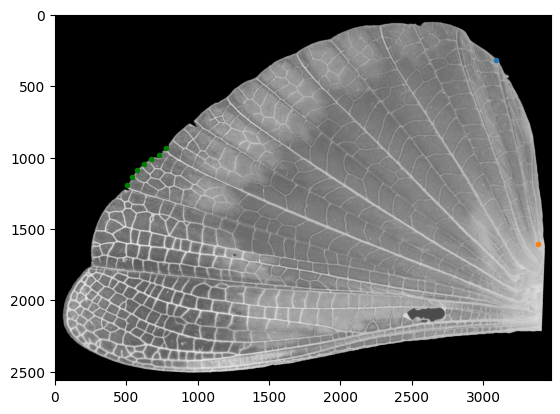

In [221]:
plt.imshow(img,cmap='gray')
plt.plot(img_x[12],img_y[12],'.')
plt.plot(img_x[19],img_y[19],'.')
# plt.plot(pt[:,0],pt[:,1],'ro')
plt.plot(result[:,0],result[:,1],'g.')

In [246]:
# find the left boundary points 
def find_rbdy(a,b,num_pt=10):
    # get line segment 
    xlen=b[0]-a[0]
    ylen=b[1]-a[1]
    dx=xlen/(num_pt+1)
    dy=ylen/(num_pt+1)
    print(dx,dy)
    

    pt=np.zeros((num_pt+2,2))

    for i in range(num_pt+2):
        pt[i,0]=a[0]+dx*i
        pt[i,1]=a[1]+dy*i
    
    bdy_pt=np.zeros((num_pt+2,2))

    dhx=dx/np.sqrt(dx*dx+dy*dy)
    dhy=dy/np.sqrt(dx*dx+dy*dy)
    for j in range(num_pt+2):
        for i in range(500):
            x=int(pt[j,0]-dhy+i)
            y=int(pt[j,1]+dhx*i)
            print(x,y)
            
            if sum(img[y,x])<0.1:
                print(i)
                bdy_pt[j,0]=x
                bdy_pt[j,1]=y
                break
            
    return bdy_pt,pt

In [253]:
a=[img_x[19],img_y[19]]
b=[img_x[12],img_y[12]]
right_bdy_pt,pt=find_rbdy(a,b)

-26.903079514723935 -117.0093770094427
3384 1606
3385 1606
3386 1605
3387 1605
3388 1605
3389 1605
3390 1604
3391 1604
3392 1604
3393 1604
3394 1604
3395 1603
3396 1603
3397 1603
3398 1603
3399 1602
3400 1602
3401 1602
3402 1602
3403 1601
3404 1601
3405 1601
3406 1601
3407 1601
3408 1600
3409 1600
3410 1600
3411 1600
3412 1599
3413 1599
3414 1599
3415 1599
3416 1599
3417 1598
3418 1598
3419 1598
3420 1598
3421 1597
3422 1597
38
3357 1489
3358 1489
3359 1488
3360 1488
3361 1488
3362 1488
3363 1487
3364 1487
3365 1487
3366 1487
3367 1486
3368 1486
3369 1486
3370 1486
3371 1486
3372 1485
3373 1485
3374 1485
3375 1485
3376 1484
3377 1484
3378 1484
3379 1484
3380 1484
3381 1483
3382 1483
3383 1483
3384 1483
3385 1482
3386 1482
3387 1482
3388 1482
3389 1482
3390 1481
3391 1481
3392 1481
3393 1481
3394 1480
3395 1480
3396 1480
3397 1480
3398 1480
3399 1479
3400 1479
3401 1479
3402 1479
3403 1478
3404 1478
3405 1478
3406 1478
3407 1478
3408 1477
3409 1477
3410 1477
3411 1477
3412 1476
3413 147

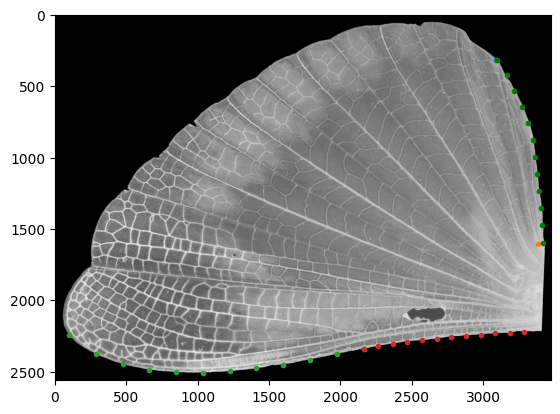

In [250]:
plt.imshow(img,cmap='gray')
plt.plot(img_x[12],img_y[12],'.')
plt.plot(img_x[19],img_y[19],'.')
# plt.plot(pt[:,0],pt[:,1],'ro')
plt.plot(result[:,0],result[:,1],'g.')
plt.plot(bdy_pt[:,0],bdy_pt[:,1],'.')
plt.plot(bdy_pt2[:,0],bdy_pt2[:,1],'.')

In [256]:
left_bdy_pt=[]
for i in range(12):
    a=[img_x[i],img_y[i]]
    b=[img_x[i+1],img_y[i+1]]
    result,pt=find_vbdy(a,b)
    left_bdy_pt.append(result)
    
a=bdy_pt[0]
b=[img_x[0],img_y[0]]
result,pt=find_vbdy(a,b)
left_bdy_pt.append(result)

7
55
75
83
71
36
0
0
17
29
28
16
0
0
0
9
16
15
13
5
0
0
6
9
9
6
0
0
0
0
11
13
14
7
0
0
12
18
24
20
10
2
2
12
16
19
18
11
4
4
21
29
32
29
17
3
3
10
16
16
16
8
10
11
0
28
31
30
20
6
7
16
20
20
12
2
4
4
3
8
10
10
7
4
0
75
98
96
76
41
8


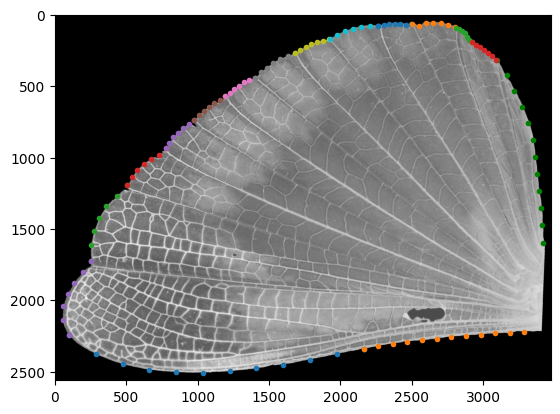

In [257]:
plt.imshow(img,cmap='gray')
# plt.plot(pt[:,0],pt[:,1],'ro')
plt.plot(right_bdy_pt[:,0],right_bdy_pt[:,1],'g.')
plt.plot(bdy_pt[:,0],bdy_pt[:,1],'.')
plt.plot(bdy_pt2[:,0],bdy_pt2[:,1],'.')
for i in range(13):
    plt.plot(left_bdy_pt[i][:,0],left_bdy_pt[i][:,1],'.')

In [ ]:
# choose dr to have uniform distributed points 

## Map the interior veins 

In [12]:
# =====================
# base_dir = "/Users/jiayinlu/Desktop/Jiayin/projects/wing/mapping/triangle_mapping/"
# rpopulation = 130
# rspecies = 4598492
# population = 130
# species = 4598506
# # =====================
# # ====================== Read in reference and original image
# #imgr=mpimg.imread(base_dir+'population_{}+FMNH_{}_hw_1.png'.format(rpopulation, rspecies))  #reference image
# img0=mpimg.imread(base_dir+'population_{}+FMNH_{}_hw_1.png'.format(population, species))    #test image
# Read image 
img_idx=10
dir="./images/"
# img=cv2.imread(dir+'0.png')
img0 = mpimg.imread(dir+'%d.png'%img_idx)

ny0=len(img0[:, 0])  # y
nx0=len(img0[0, :])  # x

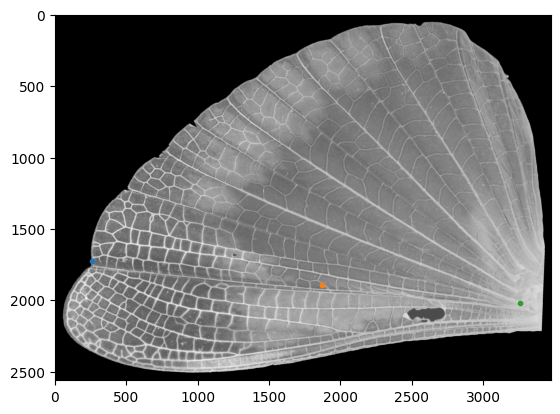

In [250]:
#######==================############=======FIND_POINTS========
# tested lm_idx=2,3,4,5,6,7
lm_idx=1
lmk1=[img_x[lm_idx+lm_idx-2],img_y[lm_idx+lm_idx-2]]
lmk2=[img_x[lm_idx+11+8],img_y[lm_idx+11+8]]
lmk3=[img_x[lm_idx+11+1],img_y[lm_idx+11+1]]
plt.imshow(img0)
plt.plot(lmk1[0],lmk1[1],'.')
plt.plot(lmk2[0],lmk2[1],'.')
plt.plot(lmk3[0],lmk3[1],'.')
#plt.plot(pt_list_x,pt_list_y,"bo",markersize=8)
# plt.plot(pt_list_x[0]+10,pt_list_y[0]-20,"ro",markersize=3)
# plt.plot(pt_list_x[4]+30,pt_list_y[4]-50,"ro",markersize=3)
# plt.plot(pt_list_x[9]+50,pt_list_y[9]-50,"ro",markersize=3)

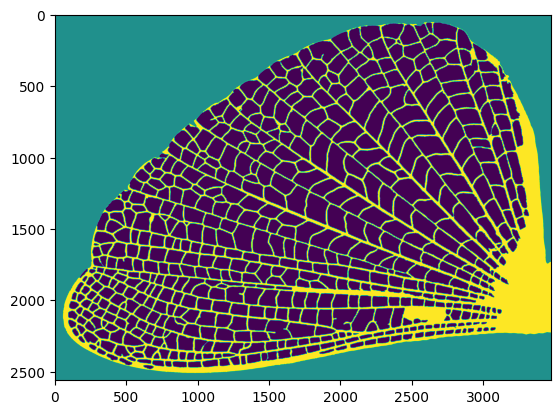

In [18]:

#0.5: background\\\\ 0: cell\\\\ vein: 1
#population_60+FMNH_4602368_hw_1.png 10.png
gray=np.load("./population_60+FMNH_4602368_hw_outline.npy")
plt.imshow(gray)

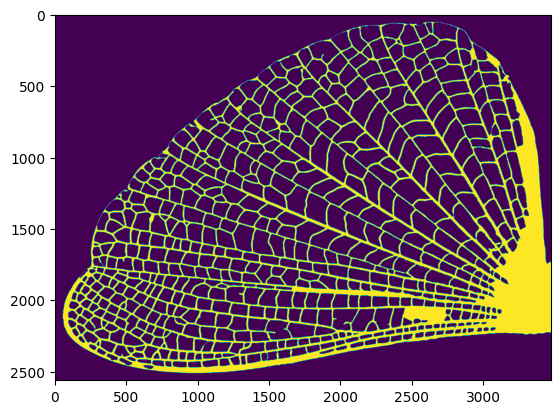

In [19]:
#vein:1 \\\\otherwise: 0
binary=gray.copy()
nnx=len(binary[0,:])
ny=len(binary[:,0])
for jj in range(0,ny):
    for ii in range(0,nnx):
        if binary[jj,ii]==0.5:
            binary[jj,ii]=0

plt.imshow(binary)


In [20]:
# B. Extract Vein Network skeleton and estimate thickness from Binary Vein data
thresh=binary.astype('uint8')

# get distance transform
distance = thresh.copy()
distance = cv2.distanceTransform(distance, distanceType=cv2.DIST_L2, maskSize=3).astype(np.float32)

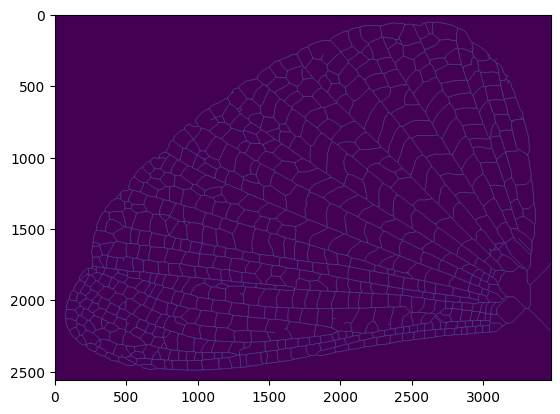

In [21]:
# get skeleton (medial axis)
binary2 = thresh.copy()
skeleton = skimage.morphology.skeletonize(binary2).astype(np.float32)

plt.imshow(skeleton)


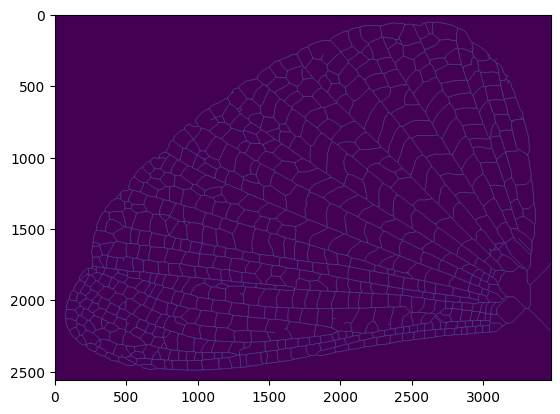

In [22]:
#C. Extract vein network (nodes, edges) from vein skeleton 
ske = skeleton.astype(np.uint16)

plt.imshow(ske)


In [23]:
# build graph from skeleton
graph = sknw.build_sknw(ske,multi=False,ring=False, iso=False)

In [24]:
#Remove disconnected component and keep only the largest connected graph
N_subs=1
G_sub=[]
largest_components=[]
for ii in range(N_subs):
  largest_components.append(sorted(nx.connected_components(graph), key=len, reverse=True)[ii])
  G_sub.append(graph.subgraph(largest_components[ii]))

G_subgraphs=nx.compose_all(G_sub)
# Get all the nodes from the graph 
all_nodes=G_subgraphs.nodes()
#draw_vein_network(G_subgraphs)


## Procedure
#1. Find 10 closest nodes

#2. Collect all edges incident to these nodes

#3. Compare these edges with the provided node, to find the correct edge that lies on the correct main vein


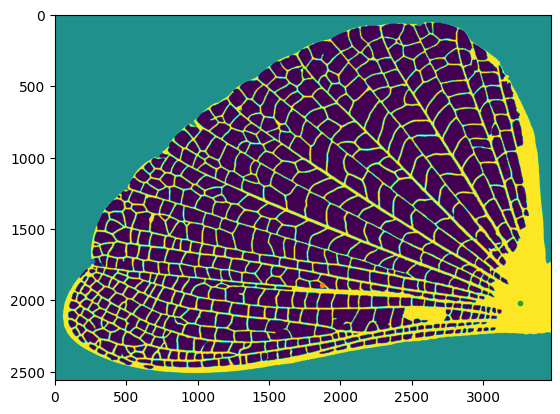

In [114]:
plt.imshow(gray)
plt.plot(lmk1[0],lmk1[1],'.')
plt.plot(lmk2[0],lmk2[1],'.')
plt.plot(lmk3[0],lmk3[1],'.')
# plt.plot(pt_list_x[0]+10,pt_list_y[0]-20,"ro",markersize=3)
# plt.plot(pt_list_x[4]+30,pt_list_y[4]-50,"mo",markersize=3)
# plt.plot(pt_list_x[9]+50,pt_list_y[9]-50,"bo",markersize=3)

In [26]:
def unit_vector(vector):
    """ Returns the unit vector of the vector.  """
    return vector / np.linalg.norm(vector)

def angle_between(v1, v2):
    """ Returns the angle in radians between vectors 'v1' and 'v2'::

            >>> angle_between((1, 0, 0), (0, 1, 0))
            1.5707963267948966
            >>> angle_between((1, 0, 0), (1, 0, 0))
            0.0
            >>> angle_between((1, 0, 0), (-1, 0, 0))
            3.141592653589793
    """
    v1_u = unit_vector(v1)
    v2_u = unit_vector(v2)
    return np.arccos(np.clip(np.dot(v1_u, v2_u), -1.0, 1.0))


In [129]:
#Collect nodes of graph
N_nodes=len(all_nodes)

#Collect the three points on/near vein
mid_pt=np.zeros(2)
mid_pt[0]=lmk2[0]
mid_pt[1]=lmk2[1]
mid_pt.astype(np.float32)

end_pt_l=np.zeros(2)
end_pt_l[0]=lmk1[0]
end_pt_l[1]=lmk1[1]
end_pt_l.astype(np.float32)

end_pt_r=np.zeros(2)
end_pt_r[0]=lmk3[0]
end_pt_r[1]=lmk3[1]
end_pt_r.astype(np.float32)

array([3258.5159, 2020.736 ], dtype=float32)

In [29]:
#given (ptx,pty)
#find edge line segment close to pt,
#and align with direction given by [dirlx,dirly][dirrx,dirry], l-left, r-right
def find_lineup_edge(ptx,pty,dirlx,dirly,dirrx,dirry,scaling=1):
    mid_pt=np.array([ptx,pty]).astype(np.float32)
    #Find 10 closest nodes
    dis_list=np.zeros(N_nodes)
    for i in range(N_nodes):
        node_x=all_nodes[i]['o'][1]
        node_y=all_nodes[i]['o'][0]
        mid_pt_node_dis=np.sqrt((mid_pt[0]-node_x)**2+(mid_pt[1]-node_y)**2)
        dis_list[i]=mid_pt_node_dis
    asc_dis=np.argsort(dis_list)  
    #The first 20 of asc_dis gives the index of 20 closest nodes


    #Collect all edges incident to these 20 nodes
    edge_list=[]
    for i in range(20):
        node_id=asc_dis[i]
        edge_list=edge_list+list(G_subgraphs.edges(node_id))
    N_edges=len(edge_list)



    #First, sort edges based on distance to the given node
    #Then, loop through the edges:
        #If the edge direction is within a threshold, continue:
            #if the edge length is larger than a thresdhold:
                #Choose this edge, Terminate
    edge_node_dis=np.zeros(N_edges)
    edge_length=np.zeros(N_edges)
    for i in range(N_edges):
        edge_node_id0=edge_list[i][0]
        edge_node_id1=edge_list[i][1]
        edge_x0=all_nodes[edge_node_id0]['o'][1].astype(np.float32)
        edge_y0=all_nodes[edge_node_id0]['o'][0].astype(np.float32)
        edge_x1=all_nodes[edge_node_id1]['o'][1].astype(np.float32)
        edge_y1=all_nodes[edge_node_id1]['o'][0].astype(np.float32)
        
        v=np.array([edge_x0,edge_y0]).astype(np.float32)
        w=np.array([edge_x1,edge_y1]).astype(np.float32)
        p=mid_pt
        
        l2=np.linalg.norm(w-v)
        edge_length[i]=l2
        l2=l2**2
        
        t= max(0, min(1, np.dot(p - v, w - v) / l2))
        projection = v + t * (w - v);
            
        lll=np.linalg.norm(p-projection)
        edge_node_dis[i]=lll
        
    length_thres=np.mean(edge_length)*0.5
    edge_node_dis_asc_ind=np.argsort(edge_node_dis) 

    vein_edge_id=-1
    end_pt_l=np.array([dirlx,dirly])
    end_pt_r=np.array([dirrx,dirry])
    #Loop through edges based on distance to node
    for i in edge_node_dis_asc_ind:
        #If edge length larger than threshold
        if edge_length[i]>length_thres:
            #If edge direction close to given nodes direction
            edge_node_id0=edge_list[i][0]
            edge_node_id1=edge_list[i][1]
            edge_x0=all_nodes[edge_node_id0]['o'][1].astype(np.float32)
            edge_y0=all_nodes[edge_node_id0]['o'][0].astype(np.float32)
            edge_x1=all_nodes[edge_node_id1]['o'][1].astype(np.float32)
            edge_y1=all_nodes[edge_node_id1]['o'][0].astype(np.float32)
            
            v1=np.array([edge_x0-edge_x1,edge_y0-edge_y1])
            v1=v1.astype(np.float32)
            if edge_x0>edge_x1:
                v1=np.array([edge_x1-edge_x0,edge_y1-edge_y0]).astype(np.float32)
            v2=end_pt_l-end_pt_r
            angle=angle_between(v1, v2)
            if angle<np.pi/10:
                vein_edge_id=i
                break
    edge_node_id0=edge_list[vein_edge_id][0]
    edge_node_id1=edge_list[vein_edge_id][1]
    edge_x0=all_nodes[edge_node_id0]['o'][1].astype(np.float32)
    edge_y0=all_nodes[edge_node_id0]['o'][0].astype(np.float32)
    edge_x1=all_nodes[edge_node_id1]['o'][1].astype(np.float32)
    edge_y1=all_nodes[edge_node_id1]['o'][0].astype(np.float32)
    
    xl=edge_x0
    yl=edge_y0
    xr=edge_x1
    yr=edge_y1
    if edge_x1<edge_x0:
        xl=edge_x1
        yl=edge_y1
        xr=edge_x0
        yr=edge_y0
    return xl,yl, xr,yr



In [130]:
#find closest edge from graph to midpoint-ML
#direction given by leftmost and rightmost points-ML
edge_x0,edge_y0, edge_x1,edge_y1=find_lineup_edge(mid_pt[0],mid_pt[1],end_pt_l[0],end_pt_l[1],end_pt_r[0],end_pt_r[1])


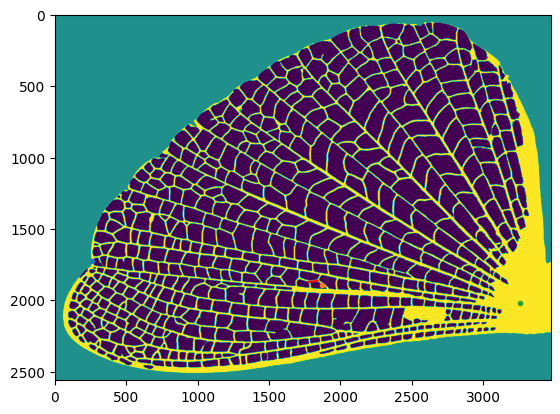

In [131]:
plt.imshow(gray)
plt.plot(lmk1[0],lmk1[1],'.')
plt.plot(lmk2[0],lmk2[1],'.')
plt.plot(lmk3[0],lmk3[1],'.')
plt.plot([edge_x0,edge_x1],[edge_y0,edge_y1],"r")    

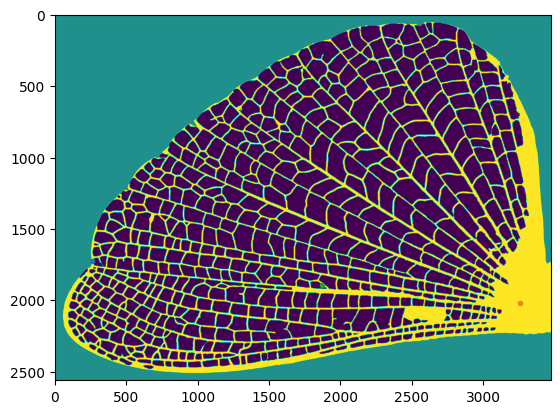

In [132]:
plt.imshow(gray)
plt.plot(end_pt_l[0],end_pt_l[1],'.')
plt.plot(end_pt_r[0],end_pt_r[1],'.')
plt.plot(mid_pt[0],mid_pt[1],'.')
# plt.plot([edge_x0,edge_x1],[edge_y0,edge_y1],"r")    

In [190]:
#Find the line y=mx+c through the vein found
#find closest edge from graph to midpoint-ML
#direction given by leftmost and rightmost points-ML
edge_x0,edge_y0, edge_x1,edge_y1=find_lineup_edge(mid_pt[0],mid_pt[1],end_pt_l[0],end_pt_l[1],end_pt_r[0],end_pt_r[1])
points = [(edge_x0,edge_y0),(edge_x1,edge_y1)]
x_coords, y_coords = zip(*points)
A = vstack([x_coords,ones(len(x_coords))]).T
m, c = lstsq(A, y_coords)[0]

/var/folders/p7/kmc6nyk1645d1b8mqwv5shlh0000gn/T/ipykernel_25107/886378971.py:8: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  m, c = lstsq(A, y_coords)[0]


In [191]:
#Find the projection point on the line near body
p1=np.array([edge_x0,edge_y0])
p2=np.array([edge_x1,edge_y1])
p3=end_pt_r
l2 = np.sum((p1-p2)**2)
t = np.sum((p3 - p1) * (p2 - p1)) / l2
projection_end_r = p1 + t * (p2 - p1)

In [192]:
#Collect the vein line segments on the right hand side
vein_line_seg_list=[]
# vein_line_seg_list.append(projection_end_r)
vein_line_seg_list.append(p2)
vein_line_seg_list.append(p1)


In [193]:
vein_line_seg_list

[array([1839., 1864.], dtype=float32), array([1779., 1871.], dtype=float32)]

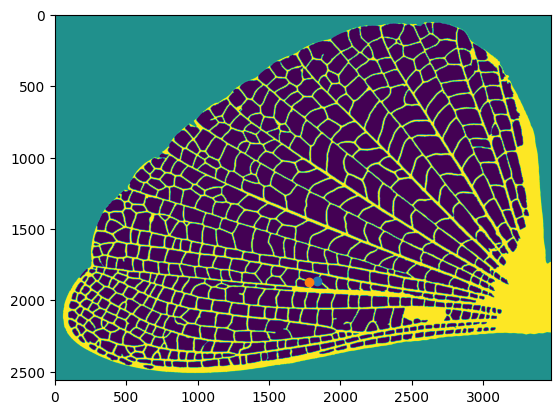

In [194]:
plt.imshow(gray)
plt.plot(vein_line_seg_list[0][0],vein_line_seg_list[0][1],'o')
plt.plot(vein_line_seg_list[1][0],vein_line_seg_list[1][1],'o')
# plt.plot(vein_line_seg_list[2][0],vein_line_seg_list[2][1],'o')

In [147]:
## good for vein 2-7

continue_search=True
len_v=np.sqrt(abs(edge_x0-edge_x1)**2+abs(edge_y0-edge_y1))
m=-1
c=-1
while continue_search:
    dir_vector=np.array([vein_line_seg_list[-1][0]-vein_line_seg_list[-2][0],vein_line_seg_list[-1][1]-vein_line_seg_list[-2][1]])
    dir_vector=dir_vector/np.linalg.norm(dir_vector)
    
    continue_calculate_newpt=True
    CTTT=1
    while continue_calculate_newpt:
        vein_pt_new=np.array([edge_x0,edge_y0]) + dir_vector*len_v*CTTT
        CTTT+=1
        gi=int(vein_pt_new[0])
        gj=int(vein_pt_new[1])
        
        if gray[gj,gi]==0.5: # if reach the background
            continue_calculate_newpt=False
            continue_search=False
            
            #Find the intersection point on the wing edge with the last line segment
            continue_find_edge_point=True
            xk=edge_x0
            while continue_find_edge_point:
                xk=xk-1
                yk=m*xk+c
                gi=int(xk)
                gj=int(yk)
                if gray[gj,gi]==0.5:
                    continue_find_edge_point=False
                    p1=np.array([xk,yk])
                    vein_line_seg_list.append(p1)
            
        else: # if not reach the background, find the interior nodes
            tmp_edge_x0,tmp_edge_y0, tmp_edge_x1,tmp_edge_y1=find_lineup_edge(vein_pt_new[0],vein_pt_new[1],vein_line_seg_list[-1][0],vein_line_seg_list[-1][1], vein_line_seg_list[-2][0],vein_line_seg_list[-2][1])
            p1=np.array([tmp_edge_x0,tmp_edge_y0])
            
            #check if find the same edge 
            if (p1[0]==vein_line_seg_list[-1][0] and p1[1]==vein_line_seg_list[-1][1]):
                continue_calculate_newpt=True
            else:
                v1=np.array([tmp_edge_x0-tmp_edge_x1, tmp_edge_y0-tmp_edge_y1])
                v2=np.array([vein_line_seg_list[-1][0]-vein_line_seg_list[-2][0], vein_line_seg_list[-1][1]-vein_line_seg_list[-2][1]])
                angle_in_between=angle_between(v1, v2)
                if(angle_in_between>np.pi/15): #check if the new edge found direction is too different
                    continue_calculate_newpt=True
                else:
                    continue_calculate_newpt=False
                
                    edge_x0=tmp_edge_x0
                    edge_y0=tmp_edge_y0 
                    edge_x1=tmp_edge_x1
                    edge_y1=tmp_edge_y1
                    p1=np.array([edge_x0,edge_y0])
                    vein_line_seg_list.append(p1)
                    
                    points = [(vein_line_seg_list[-1][0],vein_line_seg_list[-1][1]),(vein_line_seg_list[-2][0],vein_line_seg_list[-2][1])]
                    x_coords, y_coords = zip(*points)
                    A = vstack([x_coords,ones(len(x_coords))]).T
                    m, c = lstsq(A, y_coords)[0]

/var/folders/p7/kmc6nyk1645d1b8mqwv5shlh0000gn/T/ipykernel_25107/1110696162.py:60: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  m, c = lstsq(A, y_coords)[0]


In [196]:
# For vein 1:

continue_search=True
len_v=np.sqrt(abs(edge_x0-edge_x1)**2+abs(edge_y0-edge_y1))
m=-1
c=-1

v0=np.array([end_pt_l[0]-mid_pt[0],end_pt_l[1]-mid_pt[1]])
while continue_search:
    dir_vector=np.array([vein_line_seg_list[-1][0]-vein_line_seg_list[-2][0],vein_line_seg_list[-1][1]-vein_line_seg_list[-2][1]])
    dir_vector=dir_vector/np.linalg.norm(dir_vector)
    
    continue_calculate_newpt=True
    CTTT=1
    while continue_calculate_newpt:
        vein_pt_new=np.array([edge_x0,edge_y0]) + dir_vector*len_v*CTTT
        CTTT+=1
        gi=int(vein_pt_new[0])
        gj=int(vein_pt_new[1])
        
        if gray[gj,gi]==0.5: # if reach the background
            continue_calculate_newpt=False
            continue_search=False
            
            #Find the intersection point on the wing edge with the last line segment
            continue_find_edge_point=True
            xk=edge_x0
            while continue_find_edge_point:
                xk=xk-1
                yk=m*xk+c
                gi=int(xk)
                gj=int(yk)
                if gray[gj,gi]==0.5:
                    continue_find_edge_point=False
                    p1=np.array([xk,yk])
                    vein_line_seg_list.append(p1)
            
        else: # if not reach the background, find the interior nodes
            # tmp_edge_x0,tmp_edge_y0, tmp_edge_x1,tmp_edge_y1=find_lineup_edge(vein_pt_new[0],vein_pt_new[1],vein_line_seg_list[-1][0],vein_line_seg_list[-1][1], vein_line_seg_list[-2][0],vein_line_seg_list[-2][1])
            tmp_edge_x0,tmp_edge_y0, tmp_edge_x1,tmp_edge_y1=find_lineup_edge(vein_pt_new[0],vein_pt_new[1],end_pt_l[0],end_pt_l[1],vein_line_seg_list[-1][0],vein_line_seg_list[-1][1])
            p1=np.array([tmp_edge_x0,tmp_edge_y0])
            
            #check if find the same edge 
            if (p1[0]==vein_line_seg_list[-1][0] and p1[1]==vein_line_seg_list[-1][1]):
                continue_calculate_newpt=True
            else:
                v1=np.array([tmp_edge_x0-tmp_edge_x1, tmp_edge_y0-tmp_edge_y1])
                v2=np.array([vein_line_seg_list[-1][0]-vein_line_seg_list[-2][0], vein_line_seg_list[-1][1]-vein_line_seg_list[-2][1]])
                angle_in_between=angle_between(v1, v2)
                angle_in_between2=angle_between(v0,v1)
                if(angle_in_between>np.pi/10 or angle_in_between2>np.pi/10): #check if the new edge found direction is too different
                    continue_calculate_newpt=True
                else:
                    continue_calculate_newpt=False
                
                    edge_x0=tmp_edge_x0
                    edge_y0=tmp_edge_y0 
                    edge_x1=tmp_edge_x1
                    edge_y1=tmp_edge_y1
                    p1=np.array([edge_x0,edge_y0])
                    vein_line_seg_list.append(p1)
                    
                    points = [(vein_line_seg_list[-1][0],vein_line_seg_list[-1][1]),(vein_line_seg_list[-2][0],vein_line_seg_list[-2][1])]
                    x_coords, y_coords = zip(*points)
                    A = vstack([x_coords,ones(len(x_coords))]).T
                    m, c = lstsq(A, y_coords)[0]

/var/folders/p7/kmc6nyk1645d1b8mqwv5shlh0000gn/T/ipykernel_25107/3644386175.py:66: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  m, c = lstsq(A, y_coords)[0]


In [197]:
edge_x0,edge_y0, edge_x1,edge_y1

(262.0, 1761.0, 291.0, 1769.0)

In [198]:
vein_line_seg_list=np.array(vein_line_seg_list)

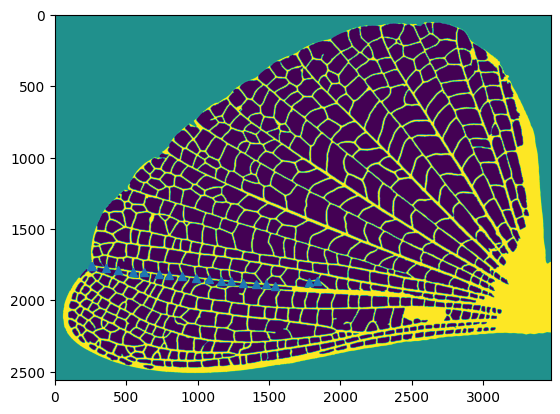

In [199]:
plt.imshow(gray)
plt.plot(vein_line_seg_list[:,0],vein_line_seg_list[:,1],"^",label="original")

In [203]:

reg=LinearRegression().fit(vein_line_seg_list[:,0].reshape(-1,1),vein_line_seg_list[:,1])

In [204]:
print("score:", reg.score(vein_line_seg_list[:,0].reshape(-1,1),vein_line_seg_list[:,1]))
reg.coef_,reg.intercept_
Ypred=reg.predict(vein_line_seg_list[:,0].reshape(-1,1))

score: 0.8679160111596642


In [245]:
vein_line_seg_list[:,0].shape

(19,)

In [249]:
np.hstack((vein_line_seg_list[:,0].reshape(-1,1),Ypred.reshape(-1,1)))

(19, 2)

In [238]:
tmp=np.vstack((vein_line_seg_list,new_r))
tmp[-1]

array([3258.5157673978615, array([2024.54185352])], dtype=object)

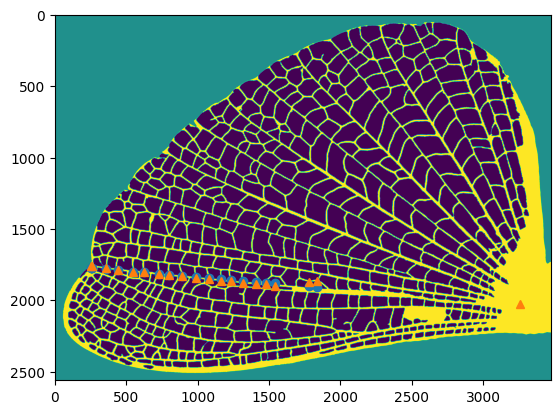

In [239]:
plt.imshow(gray)
plt.plot(vein_line_seg_list[:,0].reshape(-1,1),Ypred,'o',label="linear regression")
plt.plot(tmp[:,0],tmp[:,1],"^",label="original")

/opt/homebrew/lib/python3.9/site-packages/numpy/core/shape_base.py:65: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  ary = asanyarray(ary)
/opt/homebrew/lib/python3.9/site-packages/numpy/core/shape_base.py:65: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  ary = asanyarray(ary)


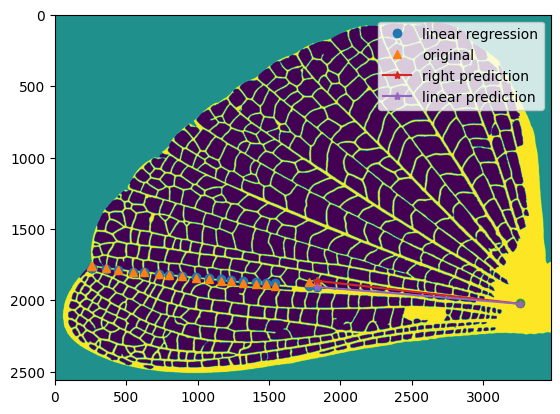

In [208]:
plt.imshow(gray)
plt.plot(vein_line_seg_list[:,0].reshape(-1,1),Ypred,'o',label="linear regression")
plt.plot(vein_line_seg_list[:,0],vein_line_seg_list[:,1],"^",label="original")
plt.plot(p3[0],p3[1],'o')
plt.plot([vein_line_seg_list[0,0],p3[0]],[vein_line_seg_list[0,1],reg.predict(p3[0].reshape(-1,1))],'*-',label="right prediction")

plt.plot([vein_line_seg_list[0,0],p3[0]],[Ypred[0],reg.predict(p3[0].reshape(-1,1))],'*-',label="linear prediction")
plt.legend()

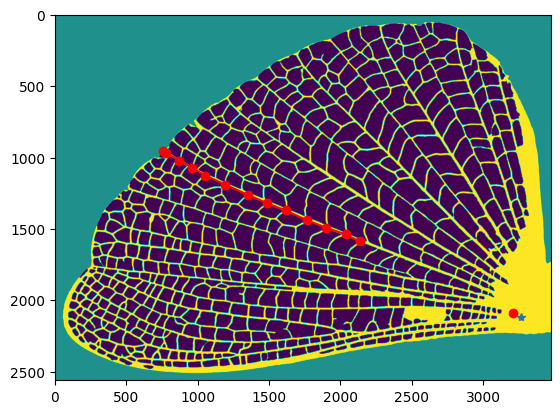

In [111]:
plt.imshow(gray)
# plt.plot(img_x[2]+10,img_y[2]-20,'ro',markersize=3) # left point
# plt.plot(img_x[2+11+8]+10,img_y[2+11+8]-10,'mo',markersize=3) # mid point
# plt.plot(img_x[2+11]+10,img_y[2+11]-10,'bo',markersize=3) # right point 
# plt.plot([edge_x0,edge_x1],[edge_y0,edge_y1],"r")
# plt.plot(p1[0],p1[1],'ro',markersize=3)    
# plt.plot(p2[0],p2[1],'ro',markersize=3)   
# plt.plot(projection_end_r[0],projection_end_r[1],"m*")
# plt.plot(projection_end_l[0],projection_end_l[1],"m*")
plt.plot(vein_line_seg_list[0,0],2087.26815117,"ro")
plt.plot(p3[0],reg.predict(p3[0].reshape(-1,1)),'*')
plt.plot(vein_line_seg_list[1:,0],vein_line_seg_list[1:,1],"ro-")

In [211]:
print(vein_line_seg_list)

[[1839.         1864.        ]
 [1779.         1871.        ]
 [1540.         1899.        ]
 [1476.         1889.        ]
 [1407.         1887.        ]
 [1320.         1880.        ]
 [1233.         1868.        ]
 [1165.         1863.        ]
 [1082.         1852.        ]
 [ 985.         1842.        ]
 [ 893.         1833.        ]
 [ 798.         1825.        ]
 [ 726.         1817.        ]
 [ 621.         1803.        ]
 [ 549.         1799.        ]
 [ 441.         1788.        ]
 [ 356.         1776.        ]
 [ 262.         1761.        ]
 [ 251.         1759.24468085]]


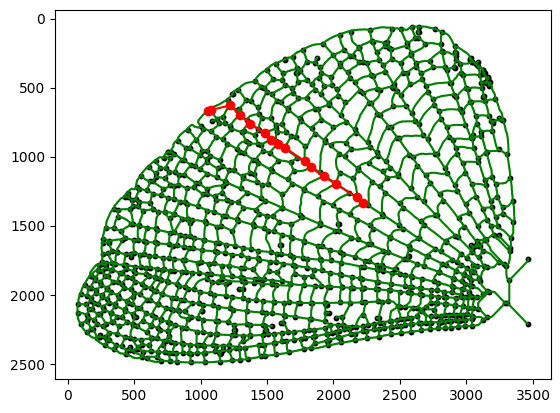

In [255]:
#Plot network and prompt points together
for (s,e) in graph.edges():
    ps = graph[s][e]['pts']
    plt.plot(ps[:,1], ps[:,0], 'g')
for i in range(len(all_nodes)):
    plt.scatter(all_nodes[i]['o'][1],all_nodes[i]['o'][0],color="k",s=10)
# plt.plot(img_x[2]+10,img_y[2]-20,'ro',markersize=3) # left point
# plt.plot(img_x[2+11+8]+10,img_y[2+11+8]-10,'mo',markersize=3) # mid point
# plt.plot(img_x[2+11]+10,img_y[2+11]-10,'bo',markersize=3) # right point 
plt.plot(vein_line_seg_list[1:,0],vein_line_seg_list[1:,1],"ro-")
plt.gca().invert_yaxis()

In [266]:
#given (ptx,pty)
#find edge line segment close to pt,
#and align with direction given by [dirlx,dirly][dirrx,dirry], l-left, r-right
#Find 10 closest nodes
def find_closest_node(pt):
    dis_list=np.zeros(N_nodes)
    for i in range(N_nodes):

        node_x=all_nodes[i]['o'][1]
        node_y=all_nodes[i]['o'][0]
        mid_pt_node_dis=np.sqrt((pt[0]-node_x)**2+(pt[1]-node_y)**2)
        dis_list[i]=mid_pt_node_dis
        
    asc_dis=np.argsort(dis_list) 
    result=np.array([all_nodes[asc_dis[0]]['o'][1],all_nodes[asc_dis[0]]['o'][0]])
    return result

In [273]:
# get line segment 
def first_vein(a,b,num_pt=5):
    xlen=b[0]-a[0]
    ylen=b[1]-a[1]
    dx=xlen/(num_pt+1)
    dy=ylen/(num_pt+1)

    pt=np.zeros((num_pt+2,2))
    result=[]
    # evenly space point in [a,b]
    for i in range(num_pt+2):
        pt[i,0]=a[0]+dx*i
        pt[i,1]=a[1]+dy*i
        node=find_closest_node(pt[i])
        result.append(node)

    return np.array(result)
    
    

In [287]:
result1=first_vein(lmk1,lmk2,num_pt=20)
result2=first_vein(lmk2,lmk3,num_pt=20)

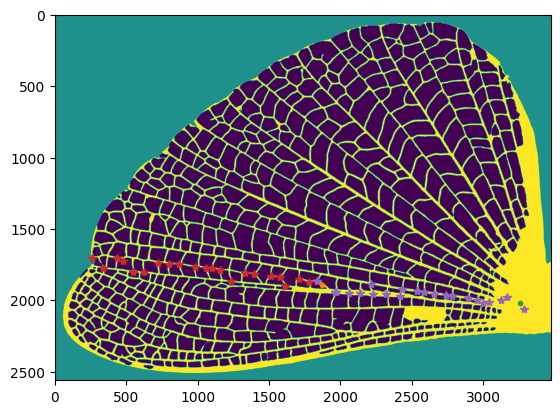

In [288]:

plt.imshow(gray)
plt.plot(lmk1[0],lmk1[1],'.')
plt.plot(lmk2[0],lmk2[1],'.')
plt.plot(lmk3[0],lmk3[1],'.')
plt.plot(result1[:,0],result1[:,1],'*')
plt.plot(result2[:,0],result2[:,1],'*')


In [289]:
final_result=np.vstack((result1,result2))
final_result.shape

(44, 2)

In [290]:
reg=LinearRegression().fit(final_result[:,0].reshape(-1,1),final_result[:,1])

In [291]:
Ypred=reg.predict(final_result[:,0].reshape(-1,1))

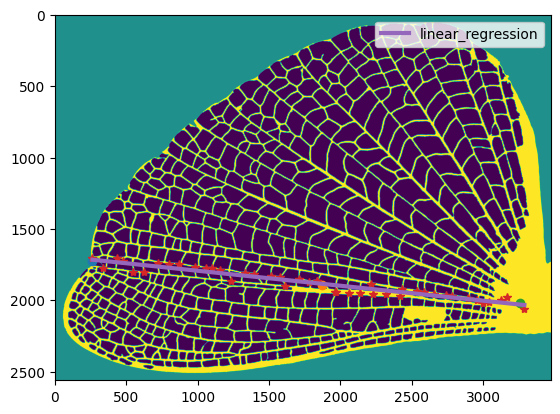

In [292]:
plt.imshow(gray)
plt.plot(lmk1[0],lmk1[1],'o')
plt.plot(lmk2[0],lmk2[1],'o')
plt.plot(lmk3[0],lmk3[1],'o')
plt.plot(final_result[:,0],final_result[:,1],'*')
plt.plot(final_result[:,0],Ypred,lw=3,label="linear_regression")
plt.legend()